# Loading the libraries

In [1]:
!pip install scikit-learn==1.2.2
!pip install imbalanced-learn==0.11.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Loading the data

In [3]:
data = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")

# Understanding the data

In [4]:
data.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
data.shape

(284807, 31)

In [7]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.369007e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.500885e-15,-5.620335e-16,1.149614e-16,-2.426963e-15,...,1.596686e-16,-3.576577e-16,2.650499e-16,4.472317e-15,5.109395e-16,1.686100e-15,-3.662399e-16,-1.225457e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
data["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

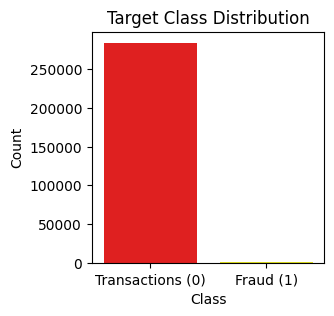

In [9]:
plt.figure(figsize=(3,3))
sns.countplot(x='Class', data=data, palette=['red', 'yellow'])
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=['Transactions (0)', 'Fraud (1)'])
plt.show()

# Handling missing values

In [10]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

There are no missing values so there is no need of handling them.

# Handling duplicates

In [11]:
data.duplicated().sum()

1081

In [12]:
full_duplicates = data[data.duplicated(keep=False)]
print(full_duplicates)

            Time        V1        V2        V3        V4        V5        V6  \
32          26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
33          26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
34          26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
35          26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
112         74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
...          ...       ...       ...       ...       ...       ...       ...   
283485  171627.0 -1.457978  1.378203  0.811515 -0.603760 -0.711883 -0.471672   
284190  172233.0 -2.667936  3.160505 -3.355984  1.007845 -0.377397 -0.109730   
284191  172233.0 -2.667936  3.160505 -3.355984  1.007845 -0.377397 -0.109730   
284192  172233.0 -2.691642  3.123168 -3.339407  1.017018 -0.293095 -0.167054   
284193  172233.0 -2.691642  3.123168 -3.339407  1.017018 -0.293095 -0.167054   

              V7        V8        V9  .

There are a total of 1081 full duplicates or duplicates. Will remove them.

In [13]:
data = data.drop_duplicates()

In [14]:
data.duplicated().sum()

0

The full duplicates or duplicates have been removed.

# Outliers

<Axes: xlabel='Time', ylabel='Amount'>

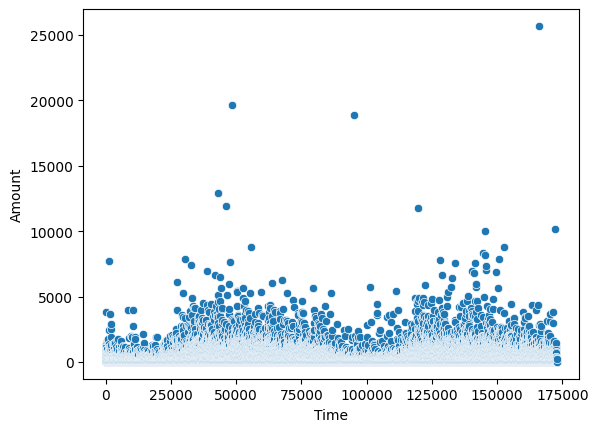

In [15]:
sns.scatterplot(x=data['Time'], y=data['Amount'])  

# Feature scaling

In [16]:
print(data[['Amount', 'Time']].describe())

              Amount           Time
count  283726.000000  283726.000000
mean       88.472687   94811.077600
std       250.399437   47481.047891
min         0.000000       0.000000
25%         5.600000   54204.750000
50%        22.000000   84692.500000
75%        77.510000  139298.000000
max     25691.160000  172792.000000


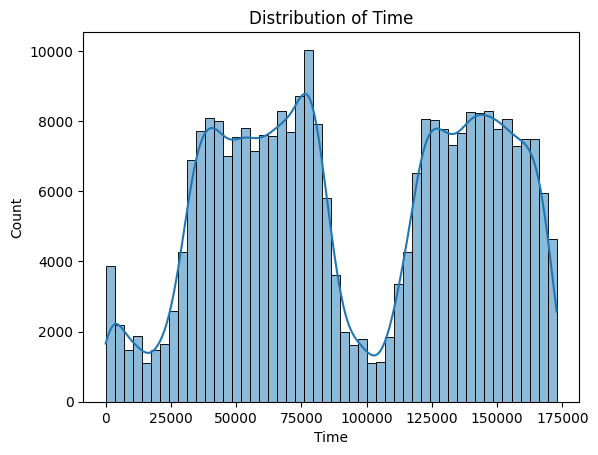

In [17]:
sns.histplot(data['Time'], bins=50, kde=True)
plt.title('Distribution of Time')
plt.show()

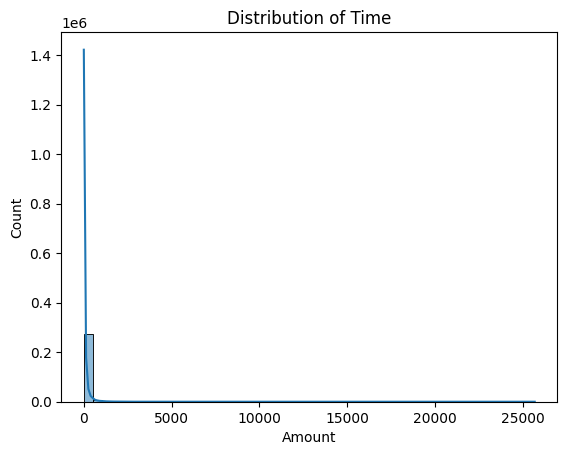

In [18]:
sns.histplot(data['Amount'], bins=50, kde=True)
plt.title('Distribution of Time')
plt.show()

In [19]:
from scipy.stats import skew
print("Skewness of Amount:", skew(data['Amount']))
print("Skewness of Time:", skew(data['Time']))

Skewness of Amount: 16.978713606547597
Skewness of Time: -0.0355804581282734


If skewness is near 0 → roughly symmetric

If skewness > 1 or < -1 → highly skewed

Between -1 and 1 → moderately skewed or roughly symmetric

Therefore, amount is highly skewed and time is almost symmetric.


In [20]:
data['Amount_log'] = np.log1p(data['Amount']) 
scaler = StandardScaler()
data['Amount_scaled'] = scaler.fit_transform(data[['Amount_log']])

To reduce skewness log transform is used and then scaled.

In [21]:
data['Time_scaled'] = scaler.fit_transform(data[['Time']])

Time is only scaled as its almost symmetric.

Features V1, V2, … V28 are the principal components obtained with PCA. So, no need of scaling or normalizing them. 

# Feature selection

In [22]:
data = data.drop(['Amount', 'Amount_log', 'Time'], axis=1)

In [23]:
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.123062,-1.996823
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-1.115298,-1.996823
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.680981,-1.996802
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.008128,-1.996802
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.669117,-1.996781


# Split the data

In [24]:
x = data.drop(columns=['Class'])
y = data["Class"]

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Train the model

In [26]:
from sklearn.svm import SVC
model = SVC(kernel='rbf', random_state=42)
model.fit(x_train, y_train)


SVC(random_state=42)

In [27]:
import joblib
joblib.dump(model, 'svm_model.pkl')  
loaded_model = joblib.load('svm_model.pkl')


Saved the trained model using joblib.

In [28]:
y_pred = loaded_model.predict(x_test)

In [29]:
random_indices = np.random.choice(len(y_pred), size=5, replace=False) 
for idx in random_indices:
    print(f"Prediction for sample {idx}: {y_pred[idx]}")

Prediction for sample 17395: 0
Prediction for sample 3038: 0
Prediction for sample 18917: 0
Prediction for sample 39624: 0
Prediction for sample 50405: 0


In [30]:
if 1 in y_pred:
    print("There is at least one prediction with class 1 (fraud).")
else:
    print("No predictions with class 1 found.")

There is at least one prediction with class 1 (fraud).


Checked if there was any fraud in the predictions.

# Evaluation metrics

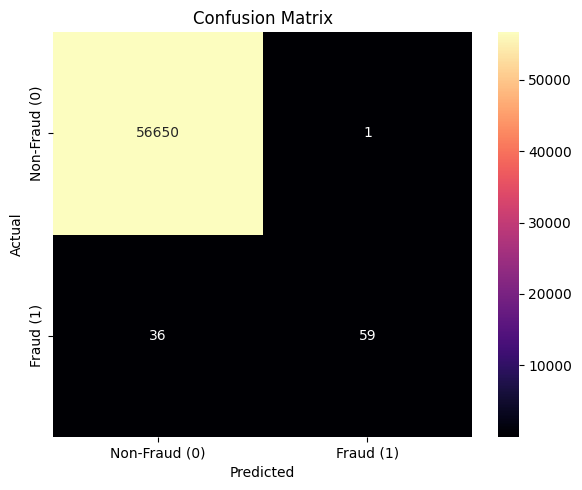


Classification Report:
               precision    recall  f1-score   support

Non-Fraud (0)       1.00      1.00      1.00     56651
    Fraud (1)       0.98      0.62      0.76        95

     accuracy                           1.00     56746
    macro avg       0.99      0.81      0.88     56746
 weighted avg       1.00      1.00      1.00     56746



In [31]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Non-Fraud (0)', 'Fraud (1)']
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

report = classification_report(y_test, y_pred, target_names=['Non-Fraud (0)', 'Fraud (1)'])
print("\nClassification Report:")
print(report)

In [32]:
print("Fraud cases in test set:", sum(y_test))


Fraud cases in test set: 95


# Balancing the dataset using SMOTE, training and testing the model

SMOTE

In [33]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train) 

In [34]:
print("Original class distribution:")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Original class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


In [35]:
print("Before SMOTE:", x_train.shape, y_train.shape)
print("After SMOTE:", x_train_resampled.shape, y_train_resampled.shape)

Before SMOTE: (226980, 30) (226980,)
After SMOTE: (453204, 30) (453204,)


Train the model

In [36]:
svmodel = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svmodel.fit(x_train_resampled, y_train_resampled)

SVC(random_state=42)

Save the model

In [37]:
joblib.dump(svmodel, 'sv_model.pkl')  
loaded_model = joblib.load('sv_model.pkl')

Make predictions

In [38]:
y_predd = loaded_model.predict(x_test)

In [39]:
if 1 in y_predd:
    print("There is at least one prediction with class 1 (fraud).")
else:
    print("No predictions with class 1 found.")

There is at least one prediction with class 1 (fraud).


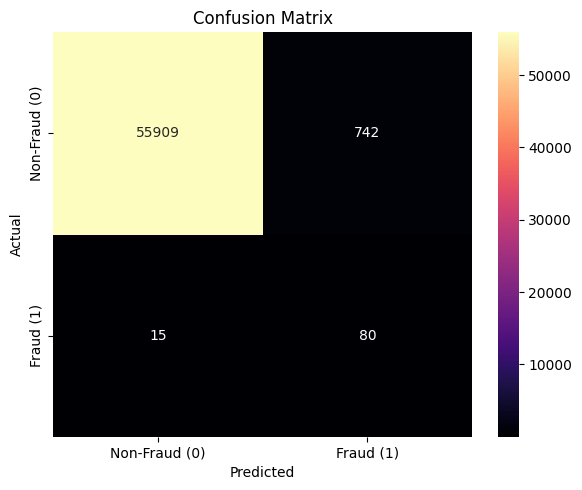


Classification Report:
               precision    recall  f1-score   support

Non-Fraud (0)       1.00      0.99      0.99     56651
    Fraud (1)       0.10      0.84      0.17        95

     accuracy                           0.99     56746
    macro avg       0.55      0.91      0.58     56746
 weighted avg       1.00      0.99      0.99     56746



In [40]:
cm = confusion_matrix(y_test, y_predd)
labels = ['Non-Fraud (0)', 'Fraud (1)']
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

report = classification_report(y_test, y_predd, target_names=['Non-Fraud (0)', 'Fraud (1)'])
print("\nClassification Report:")
print(report)